In [2]:
import pandas as pd

df = pd.read_csv("data/AAPL_1d_data.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Oct 01, 2026",330.17,332.48,328.37,330.42,330.42,"4,800,788"
1,"Sep 30, 2026",330.80,339.50,330.14,333.02,333.02,"49,931,500"
2,"Sep 29, 2026",336.97,337.09,328.70,329.40,329.40,"38,478,000"
3,"Sep 28, 2026",340.37,342.99,338.04,338.40,338.40,"32,820,800"
4,"Sep 25, 2026",336.04,341.67,334.53,341.07,341.07,"30,002,500"


In [3]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "KO"]
prices = {}

for t in tickers:
    df = pd.read_csv(f"data/{t}_1d_data.csv", thousands=",")
    df["Date"] = pd.to_datetime(df["Date"], format="%b %d, %Y")
    df = df.sort_values("Date").set_index("Date")
    prices[t] = df["Adj Close"]

prices = pd.DataFrame(prices)
returns = prices.pct_change().dropna()
returns.head()

,AAPL,MSFT,NVDA,JPM,KO
Date,,,,,
2025-10-02,0.006562,-0.007644,0.008833,-0.010168,-0.010146
2025-10-03,0.003474,0.003128,-0.006740,0.008052,0.008231
2025-10-06,-0.005135,0.021690,-0.011059,0.002104,-0.008164
2025-10-07,-0.000821,-0.008698,-0.002701,-0.004822,0.010405
2025-10-08,0.006144,0.001674,0.021993,-0.011899,-0.009991


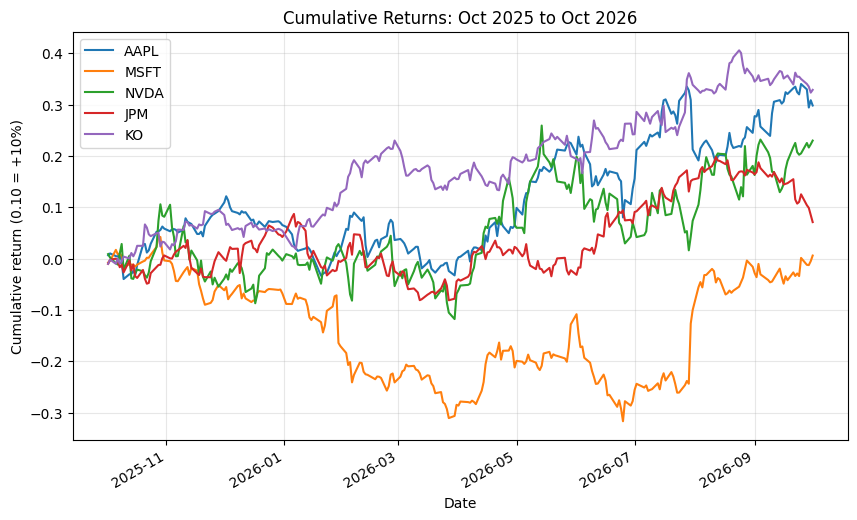

KO      32.9
AAPL    29.8
NVDA    23.0
JPM      7.1
MSFT     0.6
Name: 2026-10-01 00:00:00, dtype: float64


In [4]:
import matplotlib.pyplot as plt

cumulative = (1 + returns).cumprod() - 1

cumulative.plot(figsize=(10, 6))
plt.title("Cumulative Returns: Oct 2025 to Oct 2026")
plt.ylabel("Cumulative return (0.10 = +10%)")
plt.grid(alpha=0.3)
plt.show()

print((cumulative.iloc[-1] * 100).round(1).sort_values(ascending=False))

In [5]:
summary = pd.DataFrame({
    "Total return %": (cumulative.iloc[-1] * 100).round(1),
    "Annual volatility %": (returns.std() * (252 ** 0.5) * 100).round(1)
})
summary["Return per unit of risk"] = (
    summary["Total return %"] / summary["Annual volatility %"]
).round(2)

summary.sort_values("Total return %", ascending=False)

,Total return %,Annual volatility %,Return per unit of risk
KO,32.9,18.8,1.75
AAPL,29.8,24.7,1.21
NVDA,23.0,37.7,0.61
JPM,7.1,22.6,0.31
MSFT,0.6,32.8,0.02


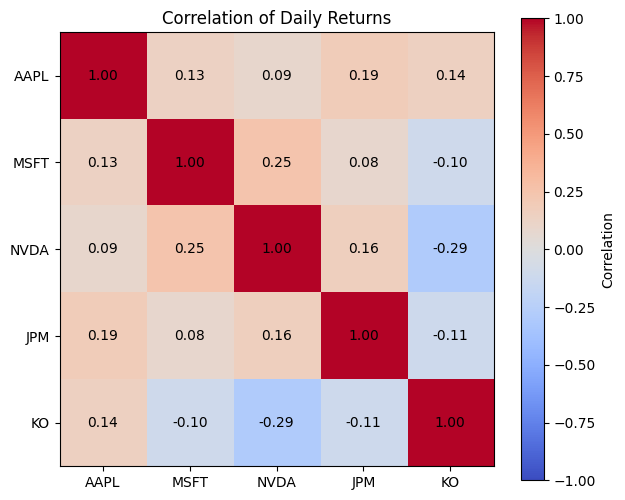

In [6]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, label="Correlation")
ax.set_title("Correlation of Daily Returns")
plt.show()

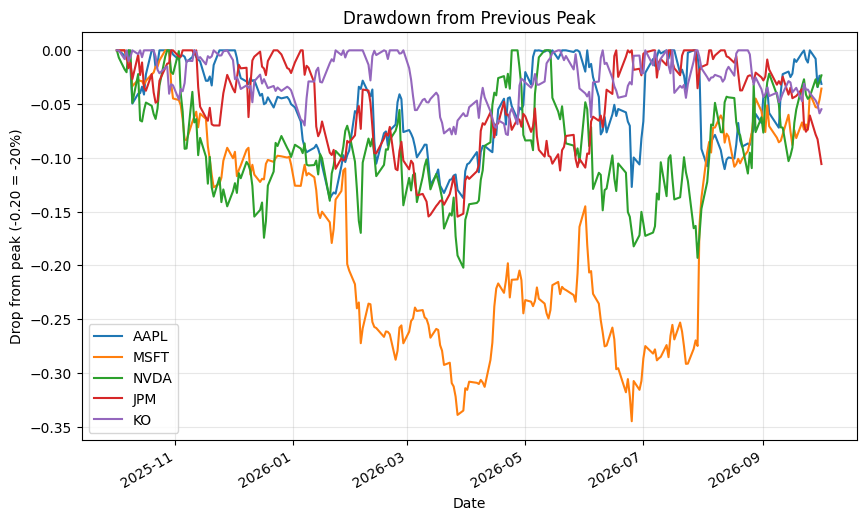

,Total return %,Annual volatility %,Return per unit of risk,Max drawdown %,Worst day (date)
KO,32.9,18.8,1.75,-7.9,2026-04-22
AAPL,29.8,24.7,1.21,-13.8,2026-01-20
NVDA,23.0,37.7,0.61,-20.2,2026-03-30
JPM,7.1,22.6,0.31,-15.5,2026-03-27
MSFT,0.6,32.8,0.02,-34.5,2026-06-25


In [7]:
wealth = (1 + returns).cumprod()
running_peak = wealth.cummax()
drawdown = wealth / running_peak - 1

drawdown.plot(figsize=(10, 6))
plt.title("Drawdown from Previous Peak")
plt.ylabel("Drop from peak (-0.20 = -20%)")
plt.grid(alpha=0.3)
plt.show()

summary["Max drawdown %"] = (drawdown.min() * 100).round(1)
summary["Worst day (date)"] = drawdown.idxmin().dt.date
summary.sort_values("Total return %", ascending=False)